### Salary prediction, episode II: make it actually work (4 points)

Your main task is to use some of the tricks you've learned on the network and analyze if you can improve __validation MAE__. Try __at least 3 options__ from the list below for a passing grade. Write a short report about what you have tried. More ideas = more bonus points. 

__Please be serious:__ " plot learning curves in MAE/epoch, compare models based on optimal performance, test one change at a time. You know the drill :)

You can use either __pytorch__ or __tensorflow__ or any other framework (e.g. pure __keras__). Feel free to adapt the seminar code for your needs. For tensorflow version, consider `seminar_tf2.ipynb` as a starting point.


In [3]:
# < A whole lot of your code > - models, charts, analysis

### A short report

Please tell us what you did and how did it work.

`<YOUR_TEXT_HERE>`, i guess...

## Recommended options

#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...


#### B) Play with pooling

There's more than one way to perform pooling:
* Max over time (independently for each feature)
* Average over time (excluding PAD)
* Softmax-pooling:
$$ out_{i, t} = \sum_t {h_{i,t} \cdot {{e ^ {h_{i, t}}} \over \sum_\tau e ^ {h_{j, \tau}} } }$$

* Attentive pooling
$$ out_{i, t} = \sum_t {h_{i,t} \cdot Attn(h_t)}$$

, where $$ Attn(h_t) = {{e ^ {NN_{attn}(h_t)}} \over \sum_\tau e ^ {NN_{attn}(h_\tau)}}  $$
and $NN_{attn}$ is a dense layer.

The optimal score is usually achieved by concatenating several different poolings, including several attentive pooling with different $NN_{attn}$ (aka multi-headed attention).

The catch is that keras layers do not inlude those toys. You will have to [write your own keras layer](https://keras.io/layers/writing-your-own-keras-layers/). Or use pure tensorflow, it might even be easier :)

#### C) Fun with words

It's not always a good idea to train embeddings from scratch. Here's a few tricks:

* Use a pre-trained embeddings from `gensim.downloader.load`. See last lecture.
* Start with pre-trained embeddings, then fine-tune them with gradient descent. You may or may not download pre-trained embeddings from [here](http://nlp.stanford.edu/data/glove.6B.zip) and follow this [manual](https://keras.io/examples/nlp/pretrained_word_embeddings/) to initialize your Keras embedding layer with downloaded weights.
* Use the same embedding matrix in title and desc vectorizer


#### D) Going recurrent

We've already learned that recurrent networks can do cool stuff in sequence modelling. Turns out, they're not useless for classification as well. With some tricks of course..

* Like convolutional layers, LSTM should be pooled into a fixed-size vector with some of the poolings.
* Since you know all the text in advance, use bidirectional RNN
  * Run one LSTM from left to right
  * Run another in parallel from right to left 
  * Concatenate their output sequences along unit axis (dim=-1)

* It might be good idea to mix convolutions and recurrent layers differently for title and description


#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea
  
Good luck! And may the force be with you!

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
data = pd.read_csv("./Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [6]:
data.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


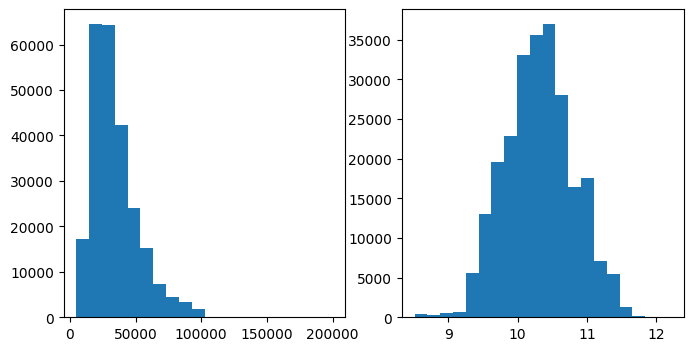

In [7]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.hist(data["SalaryNormalized"], bins=20);

plt.subplot(1, 2, 2)
plt.hist(data['Log1pSalary'], bins=20);

Our task is to predict one number, __Log1pSalary__.

To do so, our model can access a number of features:
* Free text: __`Title`__ and  __`FullDescription`__
* Categorical: __`Category`__, __`Company`__, __`LocationNormalized`__, __`ContractType`__, and __`ContractTime`__.

In [8]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
199406,71850877,Merchandiser Tonbridge/Sevenoaks,Field Based Merchandiser Part Time Permanent T...,"Sevenoaks, Kent Kent South East",Sevenoaks,part_time,NaN,Instore,Customer Services Jobs,From 6.50 to 7.50 per hour,13440,totaljobs.com,9.506065
213158,72234920,Technical Coordinator,Our Client is leading Residential Developer wh...,Peterborough Cambridgeshire East Anglia,UK,NaN,permanent,Fusion People,Trade & Construction Jobs,35000 - 40000 per annum + car/allow +pension,37500,totaljobs.com,10.532123
228607,72447205,Employer Engagement Consultant,Established almost 30 years ago they trained a...,Sheffield South Yorkshire Yorkshire,Sheffield,NaN,permanent,GPRS Recruitment,Teaching Jobs,17000 per annum + Company Benefits,17000,totaljobs.com,9.741028


In [9]:
import nltk
#TODO YOUR CODE HERE

tokenizer = nltk.tokenize.WordPunctTokenizer()
# YOUR CODE HERE
data["FullDescription"] = data["FullDescription"].apply(lambda x: ' '.join(tokenizer.tokenize(str(x).lower())))
data["Title"] = data["Title"].apply(lambda x: ' '.join(tokenizer.tokenize(str(x).lower())))

In [10]:
print("Tokenized:")
print(data["FullDescription"][2::100000])
assert data["FullDescription"][2][:50] == 'mathematical modeller / simulation analyst / opera'
assert data["Title"][54321] == 'international digital account manager ( german )'

Tokenized:
2         mathematical modeller / simulation analyst / o...
100002    a successful and high achieving specialist sch...
200002    web designer html , css , javascript , photosh...
Name: FullDescription, dtype: object


In [11]:
from collections import Counter
token_counts = Counter()
data["FullDescription"].apply(lambda x: token_counts.update(x.split(' ')))
data["Title"].apply(lambda x: token_counts.update(x.split(' ')))
#token_counts.update()
# Count how many times does each token occur in both "Title" and "FullDescription" in total
#TODO <YOUR CODE>

#dict(token_counts)

0         None
1         None
2         None
3         None
4         None
          ... 
244763    None
244764    None
244765    None
244766    None
244767    None
Name: Title, Length: 244768, dtype: object

In [12]:
print("Total unique tokens :", len(token_counts))
print('\n'.join(map(str, token_counts.most_common(n=5))))
print('...')
print('\n'.join(map(str, token_counts.most_common()[-3:])))

assert token_counts.most_common(1)[0][1] in  range(2600000, 2700000)
assert len(token_counts) in range(200000, 210000)
print('Correct!')

Total unique tokens : 202704
('and', 2657388)
('.', 2523216)
(',', 2318606)
('the', 2080994)
('to', 2019884)
...
('improvemen', 1)
('techniciancivil', 1)
('mlnlycke', 1)
Correct!


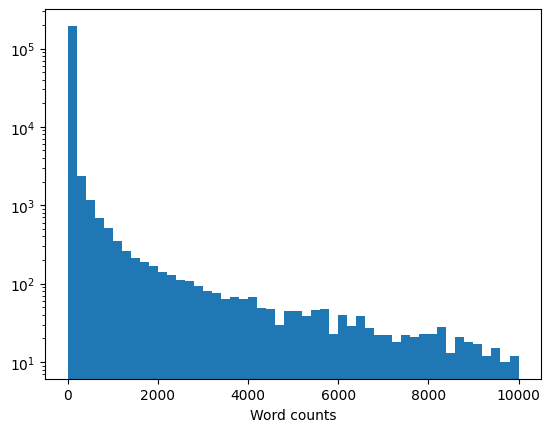

In [13]:
# Let's see how many words are there for each count
plt.hist(list(token_counts.values()), range=[0, 10**4], bins=50, log=True)
plt.xlabel("Word counts");

In [14]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = list(dict((k, v) for k, v in dict(token_counts).items() if v >= min_count).keys())#TODO<YOUR CODE HERE>

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

In [15]:
print("Vocabulary size:", len(tokens))
assert type(tokens) == list
assert len(tokens) in range(32000, 35000)
assert 'me' in tokens
assert UNK in tokens
print("Correct!")

Vocabulary size: 34158
Correct!


In [16]:
token_to_id = dict([(token, idx) for idx, token in enumerate(tokens)])#<your code here - dict of token name to its index in tokens>

In [17]:
assert isinstance(token_to_id, dict)
assert len(token_to_id) == len(tokens)
for tok in tokens:
    assert tokens[token_to_id[tok]] == tok

print("Correct!")

Correct!


In [18]:
UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))
        
    max_len = min(max(map(len, sequences)), max_len or float('inf'))
    
    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix
    
    return matrix

In [19]:
print("Lines:")
print('\n'.join(data["Title"][::100000].values), end='\n\n')
print("Matrix:")
print(as_matrix(data["Title"][::100000]))

Lines:
engineering systems analyst
hr assistant
senior ec & i engineer

Matrix:
[[    2     3     4     1     1]
 [  548  2361     1     1     1]
 [  537 10662   390   307    32]]


In [20]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

,dtype,<class 'numpy.float32'>
,separator,'='
,sparse,False
,sort,True


In [21]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F


device = 'cuda' if torch.cuda.is_available() else 'cpu'


def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))
    
    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)
    
    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values
    
    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])

In [23]:
make_batch(data_train[:3], max_len=10)

{'Title': tensor([[  537,    89,  1653,     1,     1,     1,     1],
         [ 5102,   130,    25,   172,    14,   561, 21744],
         [ 2228,    42,  1429,   109,  9254,  9255,   116]], device='cuda:0'),
 'FullDescription': tensor([[  537,    89,  1653,  2866,    44,   537,    89,  1653,    12,  2866],
         [ 5102,   130,    25,   172,    14,   561, 21744,  1331,   129,     8],
         [   49,    66,   441,    11,    12,    37,   573,    44,    42,  1429]],
        device='cuda:0'),
 'Categorical': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
 'Log1pSalary': tensor([ 9.7115, 10.4631, 10.7144], device='cuda:0')}

#### Architecture

Our basic model consists of three branches:
* Title encoder
* Description encoder
* Categorical features encoder

We will then feed all 3 branches into one common network that predicts salary.

![scheme](https://github.com/yandexdataschool/nlp_course/raw/master/resources/w2_conv_arch.png)

In [24]:
len(categorical_vectorizer.vocabulary_)

3768

In [25]:
len(tokens)

34158

In [26]:
class Permute(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.dims = dims
        
    def forward(self, x):
        x = x.permute(self.dims)
        return x

class SalaryPredictor(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #  YOUR CODE HERE
        self.n_tokens = n_tokens
        self.n_cat_features = n_cat_features
        self.text_encoder = nn.Sequential(
                                nn.Embedding(n_tokens, 32),
                                Permute(dims=[0, 2, 1]),
                                nn.Conv1d(32, hid_size, kernel_size=3),
                                )
        
        self.categorical_encoder = nn.Linear(n_cat_features, hid_size)

        self.output_layers = nn.Sequential(
                                nn.Linear(3 * hid_size, hid_size),
                                nn.Linear(hid_size, 1)
                                )
        
    def forward(self, batch):
        title_encoded = torch.max(self.text_encoder(batch["Title"]), dim=-1).values
        description_encoded = torch.max(self.text_encoder(batch["FullDescription"]), dim=-1).values
        categorical_encoded = self.categorical_encoder(batch["Categorical"])

        catted = torch.cat([title_encoded, description_encoded, categorical_encoded], dim=1)

        #print(title_encoded.shape, description_encoded.shape, categorical_encoded.shape)
        return self.output_layers(catted).squeeze(-1) 

    """
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        self.emb = nn.Embedding(n_tokens, 32)
        self.conv = nn.Conv1d(32, hid_size, kernel_size=3)

        self.linear = nn.Linear(n_cat_features, hid_size)

        self.fc = nn.Sequential(
            nn.Linear(3 * hid_size, hid_size),
            nn.Linear(hid_size, 1)
        )


    def forward(self, batch):
        title_emb = self.emb(batch["Title"]).permute(0, 2, 1)
        title_conv = self.conv(title_emb)
        max_pool_title = torch.max(title_conv, dim=-1).values

        descr_emb = self.emb(batch["FullDescription"]).permute(0, 2, 1)
        descr_conv = self.conv(descr_emb)
        max_pool_descr = torch.max(descr_conv, dim=-1).values

        cat_feat = self.linear(batch["Categorical"])

        combined = torch.cat([max_pool_title, max_pool_descr, cat_feat], dim=1)

        return self.fc(combined).squeeze(-1) 
    """

In [27]:
model = SalaryPredictor()

In [28]:
model = SalaryPredictor().to(device)
batch = make_batch(data_train[:100], device=device)
criterion = nn.MSELoss()

dummy_pred = model(batch)
dummy_loss = criterion(dummy_pred, batch[TARGET_COLUMN])
assert dummy_pred.shape == torch.Size([100])
assert len(torch.unique(dummy_pred)) > 20, "model returns suspiciously few unique outputs. Check your initialization"
assert dummy_loss.ndim == 0 and 0. <= dummy_loss <= 250., "make sure you minimize MSE"

In [29]:
def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """ iterates minibatches of data in random order """
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)

        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start : start + batch_size]], device=device, **kwargs)
            yield batch
        
        if not cycle: break

### Model training

We can now fit our model the usual minibatch way. The interesting part is that we train on an infinite stream of minibatches, produced by `iterate_minibatches` function.

In [30]:
from tqdm.auto import tqdm

BATCH_SIZE = 16
EPOCHS = 5

In [31]:
def print_metrics(model, data, batch_size=BATCH_SIZE, name="", device=torch.device('cpu'), **kw):
    squared_error = abs_error = num_samples = 0.0
    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
            batch_pred = model(batch)
            squared_error += torch.sum(torch.square(batch_pred - batch[TARGET_COLUMN]))
            abs_error += torch.sum(torch.abs(batch_pred - batch[TARGET_COLUMN]))
            num_samples += len(batch_pred)
    mse = squared_error.detach().cpu().numpy() / num_samples
    mae = abs_error.detach().cpu().numpy() / num_samples
    print("%s results:" % (name or ""))
    print("Mean square error: %.5f" % mse)
    print("Mean absolute error: %.5f" % mae)
    return mse, mae


In [84]:
model = SalaryPredictor().to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print_metrics(model, data_val, device=device)

      

epoch: 0


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.16553
Mean absolute error: 0.31196
epoch: 1


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.16237
Mean absolute error: 0.31036
epoch: 2


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.18938
Mean absolute error: 0.35347
epoch: 3


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.11549
Mean absolute error: 0.26056
epoch: 4


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.11196
Mean absolute error: 0.25436


#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...

In [146]:
class SalaryPredictorImproved(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #  YOUR CODE HERE
        self.n_tokens = n_tokens
        self.n_cat_features = n_cat_features
        self.text_encoder1 = nn.Sequential(
                                nn.Embedding(n_tokens, 32),
                                Permute(dims=[0, 2, 1]),
                                
                                nn.Conv1d(32, hid_size, kernel_size=3),
                                nn.BatchNorm1d(hid_size),
                                nn.AdaptiveAvgPool1d(1),
                                nn.Dropout(),
                                )

        self.text_encoder2 = nn.Sequential(
                                nn.Embedding(n_tokens, 32),
                                Permute(dims=[0, 2, 1]),
                                
                                nn.Conv1d(32, hid_size, kernel_size=5, padding=2),
                                nn.BatchNorm1d(hid_size),
                                nn.AdaptiveAvgPool1d(1),
                                nn.Dropout(),
                                )
        
        self.categorical_encoder = nn.Sequential( 
                                nn.Linear(n_cat_features, hid_size),
                                nn.BatchNorm1d(hid_size),
                                nn.Dropout()
                                )

        self.output_layers = nn.Sequential(
                                nn.Linear(5*hid_size, 3*hid_size),
                                #nn.BatchNorm1d(3*hid_size),
                                nn.Dropout(),
            
                                nn.Linear(3*hid_size, 2*hid_size),
                                nn.Dropout(),

                                nn.Linear(2*hid_size, hid_size),
                                #nn.AdaptiveAvgPool1d(1),
                                nn.Dropout(),
            
                                nn.Linear(hid_size, 1)
                                )
        
    def forward(self, batch):
        title_encoded1 = torch.max(self.text_encoder1(batch["Title"]), dim=-1).values
        title_encoded2 = torch.max(self.text_encoder2(batch["Title"]), dim=-1).values
        description_encoded1 = torch.max(self.text_encoder1(batch["FullDescription"]), dim=-1).values
        description_encoded2 = torch.max(self.text_encoder2(batch["FullDescription"]), dim=-1).values
        categorical_encoded = self.categorical_encoder(batch["Categorical"])

        try:
            catted = torch.cat([title_encoded1, title_encoded2, description_encoded1, description_encoded2, categorical_encoded], dim=1)
        except:
            print(title_encoded.shape, description_encoded.shape, categorical_encoded.shape)
        #print(catted.shape)
        return self.output_layers(catted).squeeze(-1) 

In [147]:
model = SalaryPredictorImproved().to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print_metrics(model, data_val, device=device)

      

epoch: 0


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.16787
Mean absolute error: 0.32079
epoch: 1


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.15473
Mean absolute error: 0.30569
epoch: 2


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.14724
Mean absolute error: 0.29850
epoch: 3


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.14523
Mean absolute error: 0.29528
epoch: 4


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.14704
Mean absolute error: 0.29626


#### B) Play with pooling

There's more than one way to perform pooling:
* Max over time (independently for each feature)
* Average over time (excluding PAD)
* Softmax-pooling:
$$ out_{i, t} = \sum_t {h_{i,t} \cdot {{e ^ {h_{i, t}}} \over \sum_\tau e ^ {h_{j, \tau}} } }$$

* Attentive pooling
$$ out_{i, t} = \sum_t {h_{i,t} \cdot Attn(h_t)}$$

, where $$ Attn(h_t) = {{e ^ {NN_{attn}(h_t)}} \over \sum_\tau e ^ {NN_{attn}(h_\tau)}}  $$
and $NN_{attn}$ is a dense layer.

The optimal score is usually achieved by concatenating several different poolings, including several attentive pooling with different $NN_{attn}$ (aka multi-headed attention).

The catch is that keras layers do not inlude those toys. You will have to [write your own keras layer](https://keras.io/layers/writing-your-own-keras-layers/). Or use pure tensorflow, it might even be easier :)

In [43]:
class Permute(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.dims = dims
        
    def forward(self, x):
        x = x.permute(self.dims)
        return x

class SalaryPredictorAttentive(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #  YOUR CODE HERE
        self.n_tokens = n_tokens
        self.n_cat_features = n_cat_features
        self.text_encoder = nn.Sequential(
                                nn.Embedding(n_tokens, 32),
                                Permute(dims=[0, 2, 1]),
                                nn.Conv1d(32, hid_size, kernel_size=3),
                                nn.Softmax(dim=1),
                                )
        
        self.categorical_encoder = nn.Linear(n_cat_features, hid_size)

        self.output_layers = nn.Sequential(
                                nn.Linear(5*hid_size, 3*hid_size),
                                #nn.BatchNorm1d(3*hid_size),
                                nn.Dropout(),
            
                                nn.Linear(3*hid_size, 2*hid_size),
                                nn.Dropout(),

                                nn.Linear(2*hid_size, hid_size),
                                nn.Softmax(dim=1),
                                nn.Dropout(),
            
                                nn.Linear(hid_size, 1)
                                )
        
    def forward(self, batch):
        title_encoded1 = torch.max(self.text_encoder(batch["Title"]), dim=-1).values
        title_encoded2 = torch.mean(self.text_encoder(batch["Title"]), dim=-1)
        description_encoded1 = torch.max(self.text_encoder(batch["FullDescription"]), dim=-1).values
        description_encoded2 = torch.mean(self.text_encoder(batch["FullDescription"]), dim=-1)
        categorical_encoded = self.categorical_encoder(batch["Categorical"])

        #print(title_encoded.shape, description_encoded.shape, categorical_encoded.shape)
        catted = torch.cat([title_encoded1, title_encoded2, description_encoded1, description_encoded2, categorical_encoded], dim=1)

        
        return self.output_layers(catted).squeeze(-1) 

In [45]:
model = SalaryPredictorAttentive().to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print_metrics(model, data_val, device=device)

      

epoch: 0


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 60.89648
Mean absolute error: 7.78821
epoch: 1


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 30.32467
Mean absolute error: 5.48491
epoch: 2


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 11.92484
Mean absolute error: 3.41824
epoch: 3


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 7.74896
Mean absolute error: 2.74688
epoch: 4


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 2.26442
Mean absolute error: 1.44249


#### C) Fun with words

It's not always a good idea to train embeddings from scratch. Here's a few tricks:

* Use a pre-trained embeddings from `gensim.downloader.load`. See last lecture.
* Start with pre-trained embeddings, then fine-tune them with gradient descent. You may or may not download pre-trained embeddings from [here](http://nlp.stanford.edu/data/glove.6B.zip) and follow this [manual](https://keras.io/examples/nlp/pretrained_word_embeddings/) to initialize your Keras embedding layer with downloaded weights.
* Use the same embedding matrix in title and desc vectorizer

#### D) Going recurrent

We've already learned that recurrent networks can do cool stuff in sequence modelling. Turns out, they're not useless for classification as well. With some tricks of course..

* Like convolutional layers, LSTM should be pooled into a fixed-size vector with some of the poolings.
* Since you know all the text in advance, use bidirectional RNN
  * Run one LSTM from left to right
  * Run another in parallel from right to left 
  * Concatenate their output sequences along unit axis (dim=-1)

* It might be good idea to mix convolutions and recurrent layers differently for title and description

#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea

In [46]:
class SalaryPredictorSuper(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #  YOUR CODE HERE
        self.n_tokens = n_tokens
        self.n_cat_features = n_cat_features
        self.text_encoder = nn.Sequential(
                                nn.Embedding(n_tokens, 32),
                                Permute(dims=[0, 2, 1]),
                                
                                nn.Conv1d(32, hid_size, kernel_size=3),
                                nn.BatchNorm1d(hid_size),
                                nn.AdaptiveAvgPool1d(1),
                                nn.Dropout(),
                                nn.Softmax(dim=1),
                                )
        
        self.categorical_encoder = nn.Sequential( 
                                nn.Linear(n_cat_features, hid_size),
                                nn.BatchNorm1d(hid_size),
                                nn.Dropout()
                                )

        self.output_layers = nn.Sequential(
                                nn.Linear(5*hid_size, 3*hid_size),
                                #nn.BatchNorm1d(3*hid_size),
                                nn.Dropout(),
            
                                nn.Linear(3*hid_size, 2*hid_size),
                                nn.Dropout(),

                                nn.Linear(2*hid_size, hid_size),
                                nn.Softmax(dim=1),
                                nn.Dropout(),
            
                                nn.Linear(hid_size, 1)
                                )
        
    def forward(self, batch):
        title_encoded1 = torch.max(self.text_encoder(batch["Title"]), dim=-1).values
        title_encoded2 = torch.mean(self.text_encoder(batch["Title"]), dim=-1)
        description_encoded1 = torch.max(self.text_encoder(batch["FullDescription"]), dim=-1).values
        description_encoded2 = torch.mean(self.text_encoder(batch["FullDescription"]), dim=-1)
        categorical_encoded = self.categorical_encoder(batch["Categorical"])

        #print(title_encoded.shape, description_encoded.shape, categorical_encoded.shape)
        catted = torch.cat([title_encoded1, title_encoded2, description_encoded1, description_encoded2, categorical_encoded], dim=1)

        
        return self.output_layers(catted).squeeze(-1) 

In [48]:
class EarlyStopping:
    def __init__(self, tolerance=5, min_delta=0.01):

        self.tolerance = tolerance
        self.min_delta = min_delta
        self.counter = 0
        self.early_stop = False

    def __call__(self, last, this):
        if np.abs(last - this) < self.min_delta:
            self.counter +=1
            if self.counter >= self.tolerance:  
                self.early_stop = True

In [50]:
model = SalaryPredictorSuper().to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = torch.optim.SGD(model.parameters(), lr=1e-4) #sgd дает лучший результат сразу, но adam быстрее сходится
early_stopping = EarlyStopping()
last_mse, last_mae = 0, 0
mses, maes = [], []

for epoch in range(100):
    print(f"epoch: {epoch}")
    model.train()
    for i, batch in tqdm(enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)),
            total=len(data_train) // BATCH_SIZE
        ):
        pred = model(batch)
        
        loss = criterion(pred, batch[TARGET_COLUMN])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    mse, mae = print_metrics(model, data_val, device=device)
    
    early_stopping(last_mse, mse)
    if early_stopping.early_stop:
      print("We are at epoch:", i)
      break

    mses += [mse]
    maes += [mae]
    last_mse, last_mae = mse, mae

      

epoch: 0


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.23846
Mean absolute error: 0.39277
epoch: 1


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.23113
Mean absolute error: 0.38671
epoch: 2


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.19633
Mean absolute error: 0.35479
epoch: 3


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.17527
Mean absolute error: 0.33301
epoch: 4


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.16838
Mean absolute error: 0.32550
epoch: 5


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.16417
Mean absolute error: 0.32128
epoch: 6


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.16079
Mean absolute error: 0.31731
epoch: 7


  0%|          | 0/12238 [00:00<?, ?it/s]

 results:
Mean square error: 0.15910
Mean absolute error: 0.31448
We are at epoch: 12238


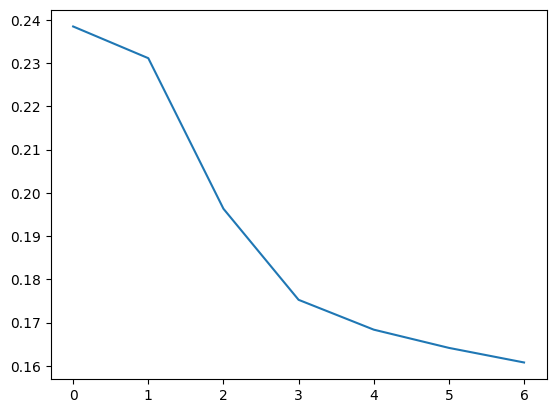

In [52]:
plt.plot(mses)

In [53]:
torch.save(model, 'best_model')